## OCR Model 

Le bloc complet pour pouvoir créer un modèle nécessite : 

- le modèle CNN
- Le dataset qui représente les données 
- L'entraînement sur les données que nous possédons 
- Une prédiction

## 1. Le modèle CNN

In [1]:
# import torch
# import torch.nn as nn

# class CNN(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.conv = nn.Sequential(
#             nn.Conv2d(1, 32, 3),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, 3),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
#         )
        
#         self.fc = nn.Sequential(
#             nn.Linear(64*5*5, 128),
#             nn.ReLU(),
#             nn.Linear(128, num_classes)
#         )

#     def forward(self, x):
#         x = self.conv(x)
#         x = x.view(x.size(0), -1)
#         return self.fc(x)

## 2. Dataset 

Tout d'abord on charge le dataset 

In [12]:
from load_image_dataset import MyDataset
from torch.utils.data import DataLoader

train_dataset = MyDataset(
    "image_data/train-images-idx3-ubyte",
    "image_data/train-labels-idx1-ubyte"
)

test_dataset = MyDataset(
    "image_data/test-images-idx3-ubyte",
    "image_data/test-labels-idx1-ubyte"
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [13]:
# num_classes = len(train_dataset.mapping)

# model = CNN(num_classes)

In [14]:
# loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
# epochs = 3

# for epoch in range(epochs):
#     model.train()
    
#     for images, labels in train_loader:
#         outputs = model(images)
#         loss = loss_fn(outputs, labels)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
    
#     print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.3914996087551117
Epoch 2, Loss: 0.6142654418945312
Epoch 3, Loss: 0.3817155659198761


## La prédiction

In [16]:
# model.eval()

# y_true = []
# y_pred = []

# with torch.no_grad():
#     for images, labels in test_loader:
#         outputs = model(images)
#         _, preds = torch.max(outputs, 1)
        
#         y_true.extend(labels.numpy())
#         y_pred.extend(preds.numpy())

In [17]:
# from sklearn.metrics import confusion_matrix

# cm = confusion_matrix(y_true, y_pred)

## 1. Imports

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from student_dataset.load_image_dataset import MyDataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score

## 2. Dataset + Loader

In [21]:
train_dataset = MyDataset(
    "student_dataset/image_data/train-images-idx3-ubyte",
    "student_dataset/image_data/train-labels-idx1-ubyte"
)

test_dataset = MyDataset(
    "student_dataset/image_data/test-images-idx3-ubyte",
    "student_dataset/image_data/test-labels-idx1-ubyte"
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

## 3. Modèle CNN

In [22]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

## 4. Initialisation 

In [23]:
num_classes = len(train_dataset.mapping)

model = CNN(num_classes)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 5. Entraînement 

In [24]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 5568.7606
Epoch 2, Loss: 4268.9370
Epoch 3, Loss: 3998.3669
Epoch 4, Loss: 3842.6778
Epoch 5, Loss: 3732.0184


## 6. Prédiction

In [25]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

## 7. Accuracy 

In [26]:
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8636641077001109


## 8. Confusion Matrix 

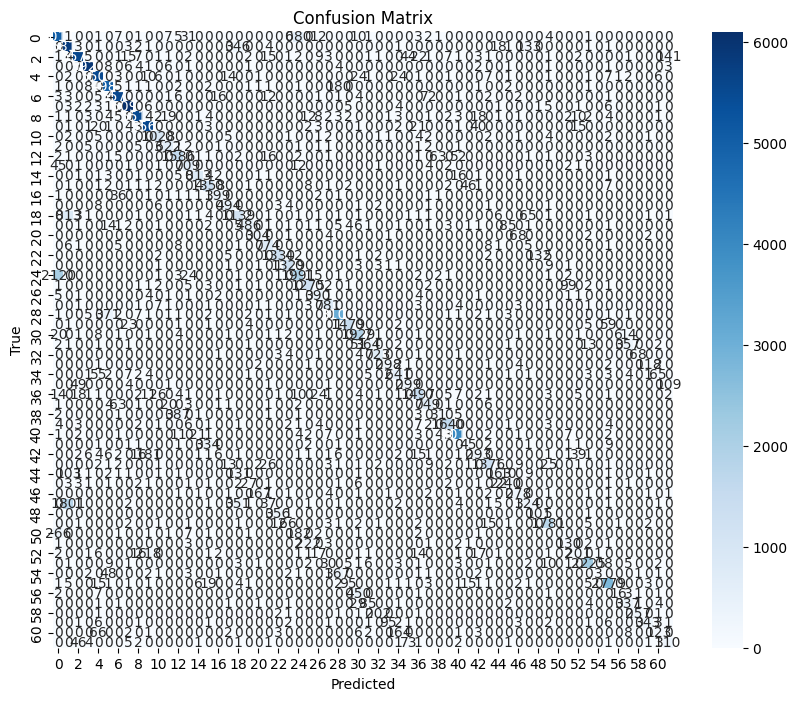

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## 9. Visualisation des erreurs 

In [28]:
# afficher quelques erreurs
errors = []

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        errors.append(i)

print("Nombre d'erreurs:", len(errors))

Nombre d'erreurs: 15859
